In [1]:
import torch
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForObjectDetection

import matplotlib.pyplot as plt
from PIL import ImageDraw

### Load CPPE-5 dataset


In [2]:
cppe5 = load_dataset("cppe-5")
print(cppe5)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.14M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/29 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 29
    })
})


_Make validation split_


In [3]:
split = cppe5["train"].train_test_split(test_size=0.15, seed=42)

train_raw = split["train"]
val_raw = split["test"]
test_raw = cppe5["test"]

print("Train:", len(train_raw))
print("Val  :", len(val_raw))
print("Test :", len(test_raw))

Train: 850
Val  : 150
Test : 29


_Label names_


In [4]:
label_names = ["Coverall", "Face_Shield", "Gloves", "Goggles", "Mask"]

id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

print(id2label)

{0: 'Coverall', 1: 'Face_Shield', 2: 'Gloves', 3: 'Goggles', 4: 'Mask'}


_Show one raw sample_


Image ID: 9
Image size: (200, 200)
Categories: [4, 4, 0]
BBoxes: [[146.0, 86.0, 54.0, 40.0], [33.0, 22.0, 18.0, 17.0], [2.0, 3.0, 69.0, 197.0]]


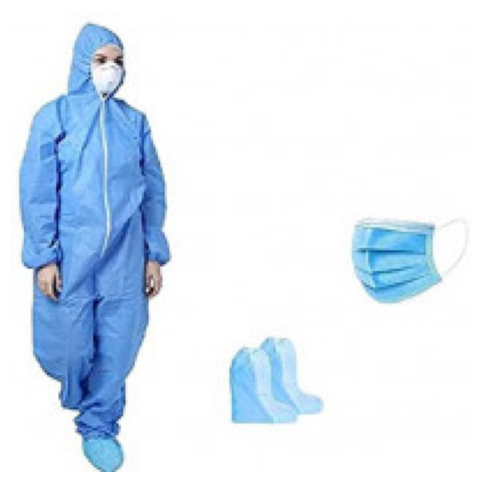

In [5]:
sample = train_raw[0]

image = sample["image"]
objects = sample["objects"]

print("Image ID:", sample["image_id"])
print("Image size:", image.size)
print("Categories:", objects["category"])
print("BBoxes:", objects["bbox"])

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

### Draw ground-truth boxes


In [6]:
def draw_ground_truth(image, objects, id2label):
    image = image.copy()
    draw = ImageDraw.Draw(image)
    
    for category, bbox in zip(objects["category"], objects["bbox"]):
        x, y, w, h = bbox
        x2 = x + w
        y2 = y + h
        draw.rectangle([x, y, x2, y2], outline="lime", width=3)
        draw.text((x, y), id2label[int(category)], fill="lime")
    
    return image

_Visualize ground truth_


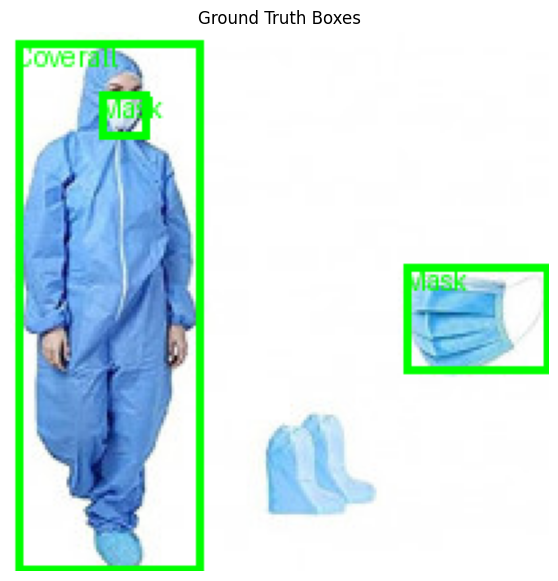

In [7]:
gt_image = draw_ground_truth(sample["image"], sample["objects"], id2label)

plt.figure(figsize=(7, 7))
plt.imshow(gt_image)
plt.axis("off")
plt.title("Ground Truth Boxes")
plt.show()

### Load image processor


In [8]:
MODEL_NAME = "microsoft/conditional-detr-resnet-50"
IMAGE_SIZE = 480

image_processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME,
    do_resize=True,
    size={"max_height": IMAGE_SIZE, "max_width": IMAGE_SIZE},
    do_pad=True,
    pad_size={"height": IMAGE_SIZE, "width": IMAGE_SIZE},
)

print(image_processor)

preprocessor_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

The image processor of type `ConditionalDetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


ConditionalDetrImageProcessorFast {
  "data_format": "channels_first",
  "do_convert_annotations": true,
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ConditionalDetrImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "pad_size": {
    "height": 480,
    "width": 480
  },
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "max_height": 480,
    "max_width": 480
  }
}



### Format annotations the way DETR expects


In [9]:
def format_image_annotations_as_coco(image_id, categories, areas, bboxes):
    annotations = []
    
    for category, area, bbox in zip(categories, areas, bboxes):
        annotations.append(
            {
                "image_id" : image_id,
                "category_id" : category,
                "iscrowd" : 0,
                "area" : area,
                "bbox" : list(bbox)
            }
        )
        
    return {
        "image_id" : image_id,
        "annotations" : annotations
    }

### Custom dataset class


In [15]:
class CPPE5DetectionDataset(Dataset):
    def __init__(self, hf_dataset, image_processor):
        self.dataset = hf_dataset
        self.image_processor = image_processor
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        item = self.dataset[index]
        
        image = item["image"].convert("RGB")
        image_id = item["image_id"]
        objects = item["objects"]
        
        annotations = format_image_annotations_as_coco(
            image_id=image_id,
            categories=objects["category"],
            areas=objects["area"],
            bboxes=objects["bbox"]
        )
        
        encoding = self.image_processor(
            images=image,
            annotations=annotations,
            return_tensors="pt"
        )
        
        pixel_values = encoding["pixel_values"].squeeze(0)
        pixel_mask = encoding["pixel_mask"].squeeze(0)
        labels = encoding["labels"][0]

        return {
            "pixel_values": pixel_values,
            "pixel_mask": pixel_mask,
            "labels": labels,
        }

_Build train/val/test datasets_


In [16]:
train_dataset = CPPE5DetectionDataset(train_raw, image_processor)
val_dataset = CPPE5DetectionDataset(val_raw, image_processor)
test_dataset = CPPE5DetectionDataset(test_raw, image_processor)

print(len(train_dataset), len(val_dataset), len(test_dataset))

850 150 29


_Custom collate function_


In [12]:
def collate_fn(batch):
    return {
        "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
        "pixel_mask": torch.stack([x["pixel_mask"] for x in batch]),
        "labels": [x["labels"] for x in batch],
    }

_DataLoaders_


In [17]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

_Inspect one batch_


In [18]:
batch = next(iter(train_loader))

print("pixel_values shape:", batch["pixel_values"].shape)
print("pixel_mask shape  :", batch["pixel_mask"].shape)
print("number of label dicts:", len(batch["labels"]))
print("keys in one label dict:", batch["labels"][0].keys())
print("class_labels:", batch["labels"][0]["class_labels"])
print("boxes shape:", batch["labels"][0]["boxes"].shape)

pixel_values shape: torch.Size([4, 3, 480, 480])
pixel_mask shape  : torch.Size([4, 480, 480])
number of label dicts: 4
keys in one label dict: KeysView({'size': tensor([480, 480]), 'image_id': tensor([481]), 'class_labels': tensor([4, 4]), 'boxes': tensor([[0.2283, 0.2305, 0.0806, 0.0716],
        [0.5334, 0.2393, 0.0728, 0.0609]]), 'area': tensor([1328.5277, 1020.1537]), 'iscrowd': tensor([0, 0]), 'orig_size': tensor([1365, 2048])})
class_labels: tensor([4, 4])
boxes shape: torch.Size([2, 4])


### Load Model


In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForObjectDetection.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

model.to(device)
print(device)
print("Num object queries:", model.config.num_queries)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/588 [00:00<?, ?it/s]

ConditionalDetrForObjectDetection LOAD REPORT from: microsoft/conditional-detr-resnet-50
Key                                                                         | Status     |                                                                                      
----------------------------------------------------------------------------+------------+--------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encode

cuda
Num object queries: 300


_Helper to move labels to device_


In [20]:
def move_labels_to_device(labels, device):
    new_labels = []
    
    for label in labels:
        new_labels.append({k: v.to(device) for k, v in label.items()})

    return new_labels

*One forward pass*

In [21]:
small_batch = next(iter(train_loader))

pixel_values = small_batch["pixel_values"].to(device)
pixel_mask = small_batch["pixel_mask"].to(device)
labels = move_labels_to_device(small_batch["labels"], device)

outputs = model(
    pixel_values=pixel_values,
    pixel_mask=pixel_mask,
    labels=labels
)

print("Loss:", outputs.loss.item())
print("Logits shape:", outputs.logits.shape)
print("Pred boxes shape:", outputs.pred_boxes.shape)

Loss: 91.86721801757812
Logits shape: torch.Size([4, 300, 5])
Pred boxes shape: torch.Size([4, 300, 4])


### Train Loop

In [22]:
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0

    for batch in dataloader:
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = move_labels_to_device(batch["labels"], device)

        optimizer.zero_grad()

        outputs = model(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    return total_loss / len(dataloader)

### Validation loop

In [23]:
def evaluate_loss(model, dataloader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)
            pixel_mask = batch["pixel_mask"].to(device)
            labels = move_labels_to_device(batch["labels"], device)

            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()

    return total_loss / len(dataloader)

*Run fine-tuning*

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
epochs = 25

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss = evaluate_loss(model, val_loader, device)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print("-" * 40)

Epoch 1/25
Train Loss: 7.6778
Val Loss:   3.1122
----------------------------------------


### Inference helper

In [37]:
def predict_objects(image, model, image_processor, device, threshold=0.05):
    model.eval()

    inputs = image_processor(images=image.convert("RGB"), return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([[image.size[1], image.size[0]]], device=device)

    results = image_processor.post_process_object_detection(
        outputs,
        threshold=threshold,
        target_sizes=target_sizes
    )[0]

    return results

### Draw predictions

In [34]:
def draw_predictions(image, results, id2label):
    image = image.copy()
    draw = ImageDraw.Draw(image)

    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        x1, y1, x2, y2 = box.tolist()

        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        text = f"{id2label[int(label)]}: {float(score):.2f}"
        draw.text((x1, y1), text, fill="red")

    return image

*Test on one image*

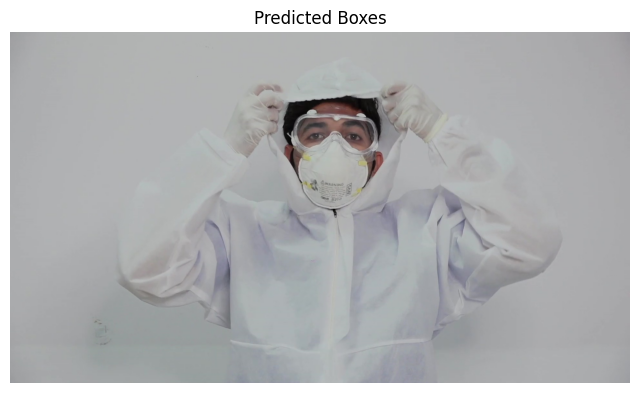

Scores : tensor([], device='cuda:0')
Labels : tensor([], device='cuda:0', dtype=torch.int64)
Boxes  : tensor([], device='cuda:0', size=(0, 4))


In [38]:
test_item = test_raw[0]
test_image = test_item["image"]

results = predict_objects(test_image, model, image_processor, device, threshold=0.4)

pred_image = draw_predictions(test_image, results, id2label)

plt.figure(figsize=(8, 8))
plt.imshow(pred_image)
plt.axis("off")
plt.title("Predicted Boxes")
plt.show()

print("Scores :", results["scores"])
print("Labels :", results["labels"])
print("Boxes  :", results["boxes"])

*Compare ground truth vs prediction*

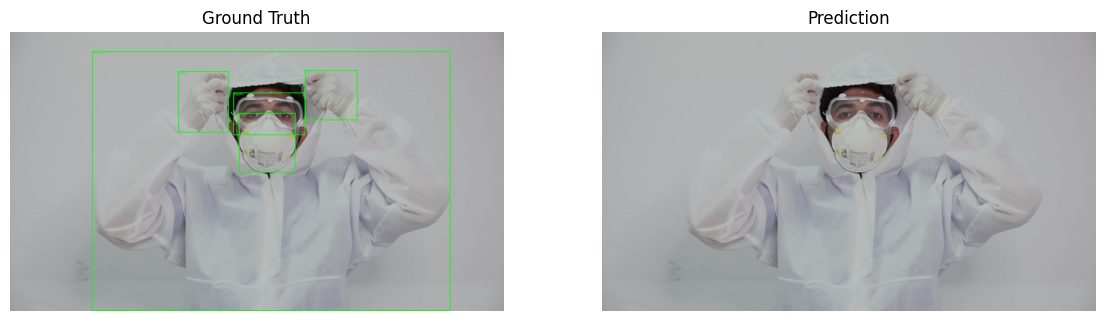

In [36]:
gt_image = draw_ground_truth(test_item["image"], test_item["objects"], id2label)
pred_image = draw_predictions(test_item["image"], results, id2label)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(gt_image)
plt.axis("off")
plt.title("Ground Truth")

plt.subplot(1, 2, 2)
plt.imshow(pred_image)
plt.axis("off")
plt.title("Prediction")

plt.show()